In [1]:
import numpy as np
from datasets import load_dataset

# Load the pusht dataset
dataset = load_dataset("lerobot/pusht", split="train")
print("Dataset loaded:")
print(dataset)
print("\nKeys in a single episode frame:")
print(dataset[0].keys())

Dataset loaded:
Dataset({
    features: ['observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index'],
    num_rows: 25650
})

Keys in a single episode frame:
dict_keys(['observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index'])


In [ ]:
import torch

frame = dataset[0]

print("=== SINGLE FRAME ===")
# X-Y position of the robot
print(f"observation.state: {frame['observation.state']}")
print(f"  shape: {torch.tensor(frame['observation.state']).shape}")

print()
# Target X-Y position (action space)
print(f"action: {frame['action']}")
print(f"  shape: {torch.tensor(frame['action']).shape}")

print()
# What demo this frame belongs to
print(f"episode_index: {frame['episode_index']}")
# Which timestep within the episode
print(f"frame_index: {frame['frame_index']}")
print(f"timestamp: {frame['timestamp']}")
# How well the robot is doing at the given timestamp
print(f"next.reward: {frame['next.reward']}")
print(f"next.done: {frame['next.done']}")
print(f"next.success: {frame['next.success']}")

In [5]:
import sys
!{sys.executable} -m pip install matplotlib pandas

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 6.1 MB/s  0:00:016.2 MB/s eta 0:00:01:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.7 MB/s  0:00:00m 5.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]


Total frames: 25650
Total episodes: 206
Average frames per episode: 124.5

Episode 0 has 161 frames


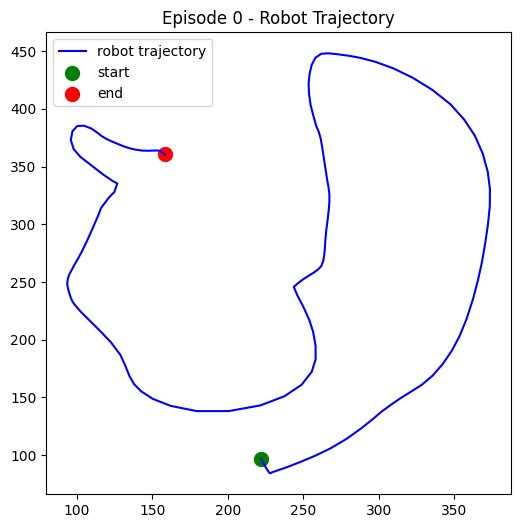

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# How many episodes are there?
episodes = set(dataset['episode_index'])
print(f"Total frames: {len(dataset)}")
print(f"Total episodes: {len(episodes)}")
print(f"Average frames per episode: {len(dataset) / len(episodes):.1f}")

# Look at one full episode
ep0_frames = [i for i, e in enumerate(dataset['episode_index']) if e == 0]
print(f"\nEpisode 0 has {len(ep0_frames)} frames")

# Plot the trajectory of episode 0
states = [dataset[i]['observation.state'] for i in ep0_frames]
actions = [dataset[i]['action'] for i in ep0_frames]

states_x = [s[0] for s in states]
states_y = [s[1] for s in states]

plt.figure(figsize=(6, 6))
plt.plot(states_x, states_y, 'b-', label='robot trajectory')
plt.scatter(states_x[0], states_y[0], c='green', s=100, label='start')
plt.scatter(states_x[-1], states_y[-1], c='red', s=100, label='end')
plt.title('Episode 0 - Robot Trajectory')
plt.legend()
plt.show()

=== ACTION STATISTICS ===
Action x range: [12.0, 511.0]
Action y range: [25.0, 511.0]
Action x mean: 228.2, std: 101.6
Action y mean: 294.0, std: 96.0

=== REWARD STATISTICS ===
Mean reward: 0.291
Success rate across all frames: 0.0%


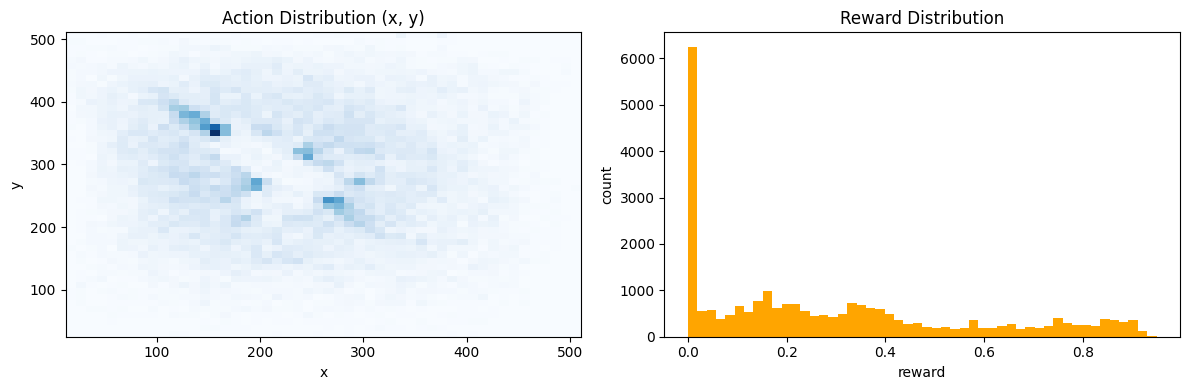

In [7]:
import numpy as np

# Extract all actions and states
all_actions = np.array(dataset['action'])
all_states = np.array(dataset['observation.state'])
all_rewards = np.array(dataset['next.reward'])
all_success = np.array(dataset['next.success'])

print("=== ACTION STATISTICS ===")
print(f"Action x range: [{all_actions[:,0].min():.1f}, {all_actions[:,0].max():.1f}]")
print(f"Action y range: [{all_actions[:,1].min():.1f}, {all_actions[:,1].max():.1f}]")
print(f"Action x mean: {all_actions[:,0].mean():.1f}, std: {all_actions[:,0].std():.1f}")
print(f"Action y mean: {all_actions[:,1].mean():.1f}, std: {all_actions[:,1].std():.1f}")

print("\n=== REWARD STATISTICS ===")
print(f"Mean reward: {all_rewards.mean():.3f}")
print(f"Success rate across all frames: {all_success.mean()*100:.1f}%")

# Plot action distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist2d(all_actions[:,0], all_actions[:,1], bins=50, cmap='Blues')
axes[0].set_title('Action Distribution (x, y)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].hist(all_rewards, bins=50, color='orange')
axes[1].set_title('Reward Distribution')
axes[1].set_xlabel('reward')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

In [8]:
# Analyze per-episode statistics
episode_stats = []

for ep_idx in sorted(episodes)[:20]:  # first 20 episodes
    ep_frames = [i for i, e in enumerate(dataset['episode_index']) if e == ep_idx]
    ep_rewards = [dataset[i]['next.reward'] for i in ep_frames]
    ep_success = [dataset[i]['next.success'] for i in ep_frames]
    
    episode_stats.append({
        'episode': ep_idx,
        'length': len(ep_frames),
        'max_reward': max(ep_rewards),
        'any_success': any(ep_success)
    })

df = pd.DataFrame(episode_stats)
print(df.to_string(index=False))
print(f"\nEpisodes with any success: {df['any_success'].sum()} / {len(df)}")

 episode  length  max_reward  any_success
       0     161    0.873257        False
       1     118    0.900152        False
       2     141    0.908086        False
       3     159    0.920348        False
       4     159    0.908956        False
       5     157    0.920946        False
       6      69    0.890051        False
       7     169    0.898501        False
       8      80    0.874618        False
       9     134    0.911932        False
      10     188    0.919286        False
      11     149    0.908278        False
      12     140    0.899556        False
      13     125    0.909134        False
      14     107    0.877874        False
      15     153    0.839021        False
      16     126    0.885468        False
      17     102    0.870470        False
      18      86    0.904934        False
      19      75    0.879921        False

Episodes with any success: 0 / 20


In [10]:
# Check success across ALL episodes
episode_stats_full = []

for ep_idx in sorted(episodes):
    ep_frames = [i for i, e in enumerate(dataset['episode_index']) if e == ep_idx]
    ep_success = [dataset[i]['next.success'] for i in ep_frames]
    ep_rewards = [dataset[i]['next.reward'] for i in ep_frames]
    
    episode_stats_full.append({
        'episode': ep_idx,
        'length': len(ep_frames),
        'max_reward': max(ep_rewards),
        'any_success': any(ep_success)
    })

df_full = pd.DataFrame(episode_stats_full)
print(f"Total episodes: {len(df_full)}")
print(f"Episodes with any success: {df_full['any_success'].sum()} / {len(df_full)}")
print(f"Average episode length: {df_full['length'].mean():.1f}")
print(f"Average max reward per episode: {df_full['max_reward'].mean():.3f}")
print(f"\nTop 5 highest reward episodes:")
print(df_full.nlargest(5, 'max_reward')[['episode', 'length', 'max_reward', 'any_success']])

Total episodes: 206
Episodes with any success: 0 / 206
Average episode length: 124.5
Average max reward per episode: 0.892

Top 5 highest reward episodes:
     episode  length  max_reward  any_success
32        32     148    0.948880        False
124      124     148    0.948477        False
120      120      65    0.940463        False
31        31      95    0.938889        False
57        57      83    0.937421        False


In [14]:
# Summary of dataset findings
print(f"=== DATASET SUMMARY FOR TRAINING ===")
print(f"Total frames: {len(dataset)}")
print(f"Total episodes: {len(episodes)}")
print(f"Average episode length: {df_full['length'].mean():.1f} frames")
print(f"Environment space: ~512x512 pixels")
print(f"Observation: (x, y) position — shape [2]")
print(f"Action: (x, y) target position — shape [2]")
print(f"Reward: continuous 0-1, mean max per episode: {df_full['max_reward'].mean():.3f}")
print(f"Success flag: strict threshold, not reliable for this dataset")
print(f"\nKey insight: reward ~0.89 average max means robot consistently")
print(f"gets close to goal but strict success threshold is rarely met.")
print(f"Use reward as primary evaluation metric, not success flag.")

=== DATASET SUMMARY FOR TRAINING ===
Total frames: 25650
Total episodes: 206
Average episode length: 124.5 frames
Environment space: ~512x512 pixels
Observation: (x, y) position — shape [2]
Action: (x, y) target position — shape [2]
Reward: continuous 0-1, mean max per episode: 0.892
Success flag: strict threshold, not reliable for this dataset

Key insight: reward ~0.89 average max means robot consistently
gets close to goal but strict success threshold is rarely met.
Use reward as primary evaluation metric, not success flag.
